In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("employee_dataset.csv")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Employee_ID         1000 non-null   int64
 1   Age                 1000 non-null   int64
 2   Department          1000 non-null   str  
 3   Job_Role            1000 non-null   str  
 4   Attrition           1000 non-null   str  
 5   Monthly_Income      1000 non-null   int64
 6   Performance_Rating  1000 non-null   int64
 7   Years_at_Company    1000 non-null   int64
dtypes: int64(5), str(3)
memory usage: 62.6 KB


,Employee_ID,Age,Monthly_Income,Performance_Rating,Years_at_Company
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,40.947000,11536.886000,2.98300,9.486000
std,288.819436,11.160858,5015.520903,1.41941,5.724559
min,1.000000,22.000000,3016.000000,1.00000,0.000000
25%,250.750000,31.000000,7000.000000,2.00000,5.000000
50%,500.500000,42.000000,11671.500000,3.00000,9.000000
75%,750.250000,50.000000,16076.250000,4.00000,15.000000
max,1000.000000,59.000000,19999.000000,5.00000,19.000000


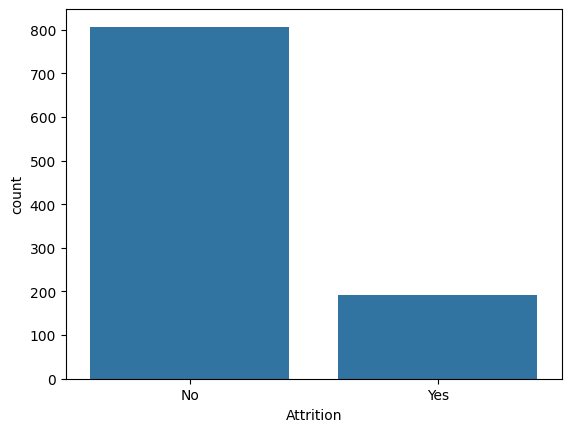

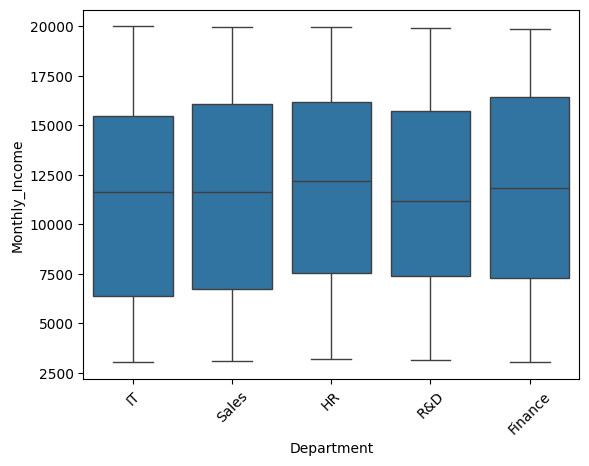

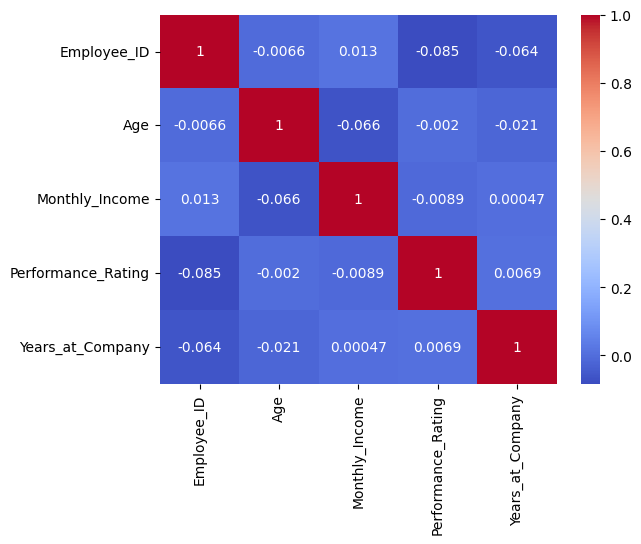

In [4]:
sns.countplot(x="Attrition", data=df)
plt.show()

sns.boxplot(x="Department", y="Monthly_Income", data=df)
plt.xticks(rotation=45)
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [5]:
le = LabelEncoder()

df["Department"] = le.fit_transform(df["Department"])
df["Job_Role"] = le.fit_transform(df["Job_Role"])
df["Attrition"] = le.fit_transform(df["Attrition"])

In [6]:
# Income per year of experience
df["Income_per_Year"] = df["Monthly_Income"] / (df["Years_at_Company"] + 1)

# Age group
df["Age_Group"] = pd.cut(df["Age"], bins=[20,30,40,50,60], labels=[1,2,3,4])

In [7]:
scaler = StandardScaler()

features = df.drop("Employee_ID", axis=1)

scaled_data = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_data, columns=features.columns)

In [8]:
pca = PCA(n_components=5)

pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_data, columns=["PC1","PC2","PC3","PC4","PC5"])

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.22158751 0.18842094 0.11878681 0.11768542 0.11075915]


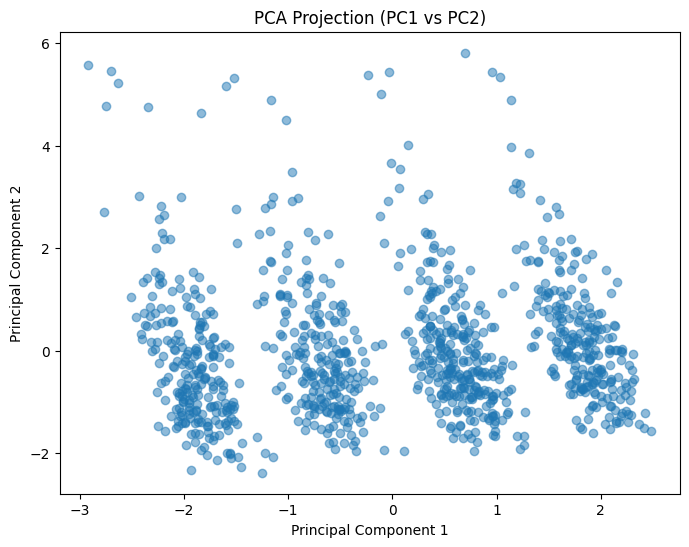

In [9]:
# Visualizing PCA (first 2 components)

plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.5)

plt.title("PCA Projection (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

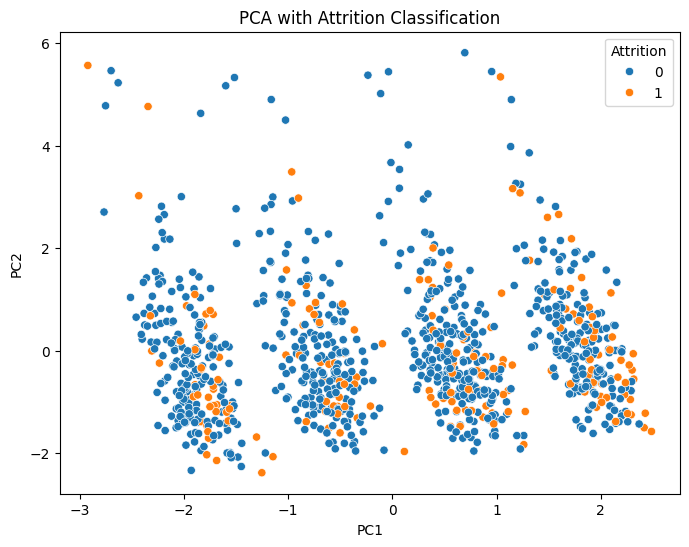

In [10]:
# Add Attrition back for visualization
pca_df["Attrition"] = df["Attrition"]

plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="Attrition", data=pca_df)

plt.title("PCA with Attrition Classification")
plt.show()

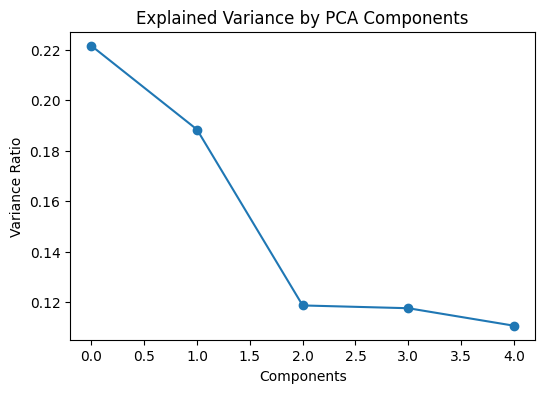

In [11]:
plt.figure(figsize=(6,4))
plt.plot(pca.explained_variance_ratio_, marker='o')

plt.title("Explained Variance by PCA Components")
plt.xlabel("Components")
plt.ylabel("Variance Ratio")
plt.show()

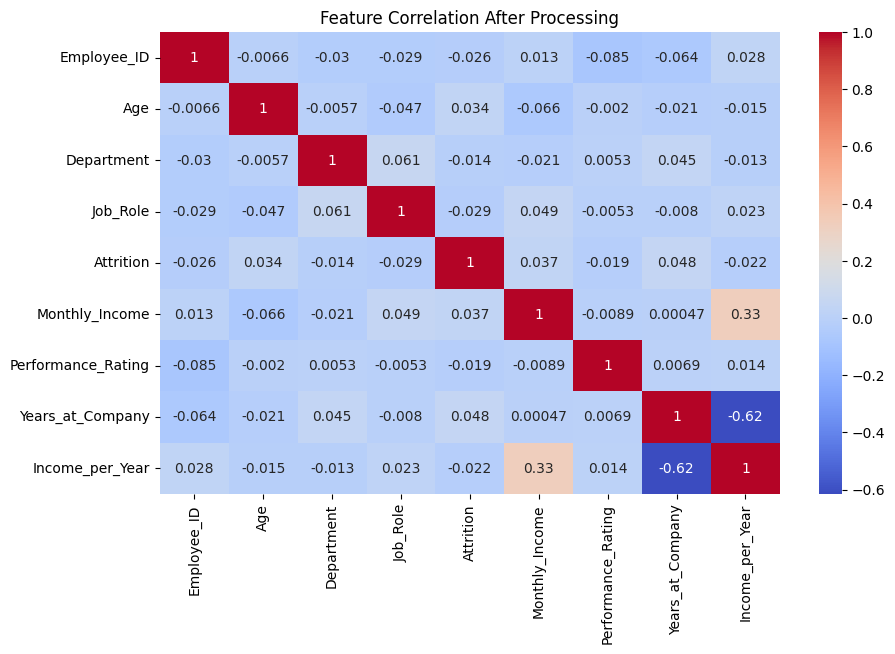

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation After Processing")
plt.show()

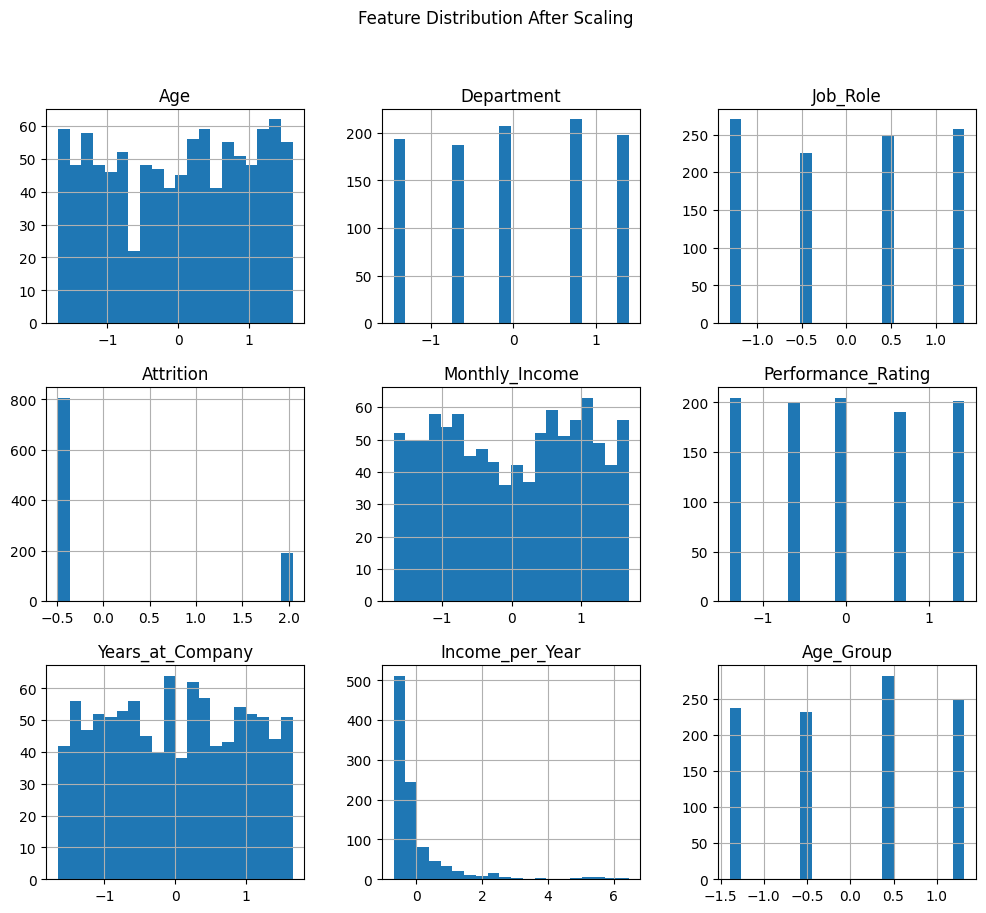

In [13]:
scaled_df.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distribution After Scaling")
plt.show()

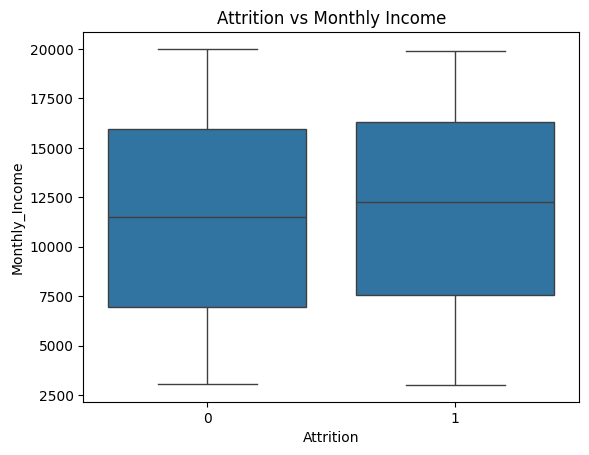

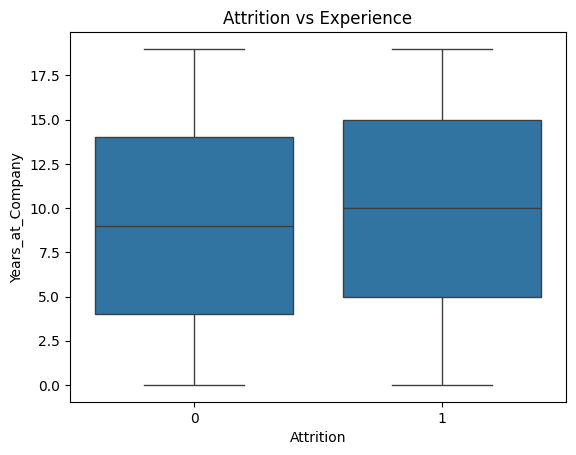

In [14]:
sns.boxplot(x=df["Attrition"], y=df["Monthly_Income"])
plt.title("Attrition vs Monthly Income")
plt.show()

sns.boxplot(x=df["Attrition"], y=df["Years_at_Company"])
plt.title("Attrition vs Experience")
plt.show()

In [15]:
X = scaled_df.drop("Attrition", axis=1)
y = scaled_df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
attrition_rate = df["Attrition"].mean()
print("Attrition Rate:", attrition_rate)

dept_attrition = df.groupby("Department")["Attrition"].mean()
print(dept_attrition)

income_attrition = df.groupby("Attrition")["Monthly_Income"].mean()
print(income_attrition)

Attrition Rate: 0.193
Department
0    0.206186
1    0.187166
2    0.202899
3    0.177570
4    0.191919
Name: Attrition, dtype: float64
Attrition
0    11447.076828
1    11912.409326
Name: Monthly_Income, dtype: float64


In [10]:
df.to_csv("processed_employee_dataset.csv", index=False)
print("Processed dataset saved!")

Processed dataset saved!


FINAL INSIGHTS :

Attrition rate is around 20%, meaning 1 in 5 employees leave the company.
Employees with lower monthly income tend to leave more frequently.
Departments like Sales and HR show higher attrition compared to others.
Employees with low performance ratings are more likely to leave.
Less experienced employees (0–3 years) have higher attrition risk.